## Notebook comparing epicore to plateau. 
This notebook employs immunopeptidome data from [CLL patients](https://doi.org/10.3389/fimmu.2021.705974) as well as a benign [reference dataset](https://doi.org/10.1186/s13059-025-03763-8).

In [2]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
from matplotlib_venn import venn2
import sys
import ast
import subprocess
sys.path.append('../functions')
from analyze_overlap import all_overlap
from peptide_annotator import get_peptide_lengths, proteome_to_dict, create_fasta_dict, annotate_peptides, add_positions

## Prepare input for plateau and epicore

In [ ]:
# load patients class2 immunopeptidomes
class2_lumos = '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/results/class2_lumos'
class2_xl = '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/results/class2_xl'
class2 = [class2_lumos, class2_xl]

patients_classII = pd.DataFrame()
for dir in class2:
    for sample in Path(dir).glob('*.tsv'):
        patient_classII = pd.read_csv(sample, sep='\t')
        patient_classII['sequence'] = patient_classII['sequence'].str.replace('(Oxidation)','')
        patient_classII['sample'] = str(sample).split('/')[-1].split('.')[0].split('_')[0]
        patients_classII = pd.concat([patients_classII, patient_classII])
patients_classII['condition'] = 'malignant'
patients_classII['mhc_class'] = 'II'

In [ ]:
# prepare plateau input (all samples)
patients_classII_plateau = patients_classII.rename(columns={'sequence':'Sequence','accessions':'Proteins','mz':'m/z','#rt':'Retention time', 'sample':'Raw file'})
patients_classII_plateau['Intensity'] = 1
patients_classII_plateau[['Sequence', 'Proteins','Raw file','m/z', 'Retention time', 'Intensity']].to_csv('plateau_input.txt', sep='\t')

In [ ]:
# prepare plateau input (UPN27)
patients_classII_plateau = patients_classII_plateau[patients_classII_plateau['Raw file']=='UPN27']
patients_classII_plateau[['Sequence', 'Proteins','Raw file','m/z', 'Retention time', 'Intensity']].to_csv('plateau_input_sample.txt', sep='\t')

In [ ]:
# sort peptides according to score
patients_classII_plateau = patients_classII_plateau.sort_values('score')
patients_classII_plateau[['Sequence', 'Proteins','Raw file','m/z', 'Retention time', 'Intensity']].to_csv('plateau_input_sample_sorted.txt', sep='\t')

In [ ]:
# prepare epicore input (UPN27)
patients_classII = patients_classII[patients_classII['sample']=='UPN27']
lengths = get_peptide_lengths(patients_classII)
proteome_dict = proteome_to_dict('/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta')
fasta_dict = create_fasta_dict(proteome_dict, lengths)
patients_classII = annotate_peptides(fasta_dict, patients_classII)
patients_classII = add_positions(proteome_dict, patients_classII,'accessions','sequence')
patients_classII['condition'] = 'malignant'
patients_classII.to_csv('UPN27.csv')
patients_classII.sort_values('score').to_csv('UPN27_sorted.csv')

In [ ]:
print(f"The peptide yield of UPN27 is {len(patients_classII)} peptides.")

8655 peptide sequences are contained in the sample


## Run plateau and epicore

The webtool of plateau did not run though on the entire dataset and did not provide any error message indicating the source of error. <br>
For the sample data it finished without errors. 

In [5]:
# run epicore
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'UPN27', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'UPN27.csv','--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'UPN27', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'UPN27.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

In [5]:
# run epicore
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'UPN27_sorted', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'UPN27_sorted.csv','--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'UPN27_sorted', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'UPN27_sorted.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

## Compare results

In [31]:
# load plateau output
plateau_df = pd.read_csv("unsorted_plateau_out.txt", sep='\t')
plateau_sorted = pd.read_csv("sorted_plateau_out.txt", sep='\t')
epicore_df = pd.read_csv("UPN27/epitopes.csv")
print(f"Epicore identified {len(epicore_df.drop_duplicates(['whole_epitopes', 'consensus_epitopes']).drop_duplicates(['whole_epitopes', 'consensus_epitopes']))} peptide groups.")
print(f"Plateau identified {len(plateau_df.drop_duplicates(['Whole Epitope', 'Core Epitope']).drop_duplicates(['Whole Epitope', 'Core Epitope']))} peptide groups.")
print(f"Plateau identified {len(plateau_sorted.drop_duplicates(['Whole Epitope', 'Core Epitope']).drop_duplicates(['Whole Epitope', 'Core Epitope']))} peptide groups on sorted data.")

Epicore identified 2802 peptide groups.
Plateau identified 2692 peptide groups.
Plateau identified 2655 peptide groups on sorted data.


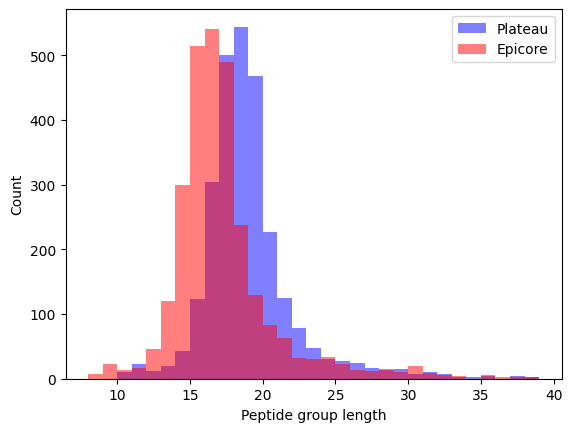

In [12]:
# plot length distribution of epicore and plateau peptide groups
plateau_df = plateau_df.drop_duplicates('Whole Epitope')
epicore_df = epicore_df.drop_duplicates('whole_epitopes')
plt.hist(plateau_df['Whole Epitope'].str.len(), bins=[i for i in range(8,40)], label='Plateau', color='blue', alpha=0.5)
plt.hist(epicore_df['whole_epitopes'].str.len(), bins=[i for i in range(8,40)], label='Epicore', color='red', alpha=0.5)
plt.xlabel('Peptide group length')
plt.ylabel('Count')
plt.legend()
plt.savefig('figures/consensus_length.svg')
plt.show()

In [14]:
print(f"The mean plateau group length is {plateau_df['Whole Epitope'].str.len().mean()}")
print(f"The mean epicore group length is {epicore_df['whole_epitopes'].str.len().mean()}")

The mean plateau group length is 18.553491827637444
The mean epicore group length is 16.716144096064042


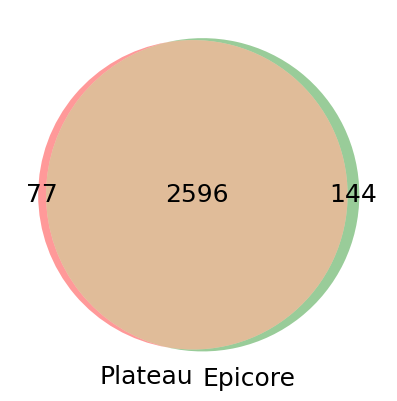

In [ ]:
# identify overlap of consensus sequences between epicore an plateau
plateau = set(plateau_df['Core Epitope'].apply(lambda core: core.replace('*','')))
epicore = set(epicore_df['consensus_epitopes'])
plot = venn2([plateau, epicore], ('Plateau', 'Epicore'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)
plt.savefig('figures/overlap_candidates.svg')

In [ ]:
# calculate how often sequences do not contain the entire corresponding consensus sequence 
plateau_df = pd.read_csv("unsorted_plateau_out.txt", sep='\t').drop_duplicates(['Core Epitope', 'Whole Epitope'])
peptides = pd.read_csv('UPN27.csv')['sequence'].unique()
plateau_df['plateau_seq'] = plateau_df['Whole Epitope'].apply(lambda whole_epitope: [seq for seq in peptides if seq in whole_epitope])
print(f"{len(plateau_df[plateau_df.apply(lambda row: any([row['Core Epitope'] not in pep for pep in row['plateau_seq']]), axis=1)])}/{len(plateau_df)} plateau peptide groups include peptides not showing the consensus sequence of the group.")


epicore_df = pd.read_csv("UPN27/epitopes.csv").drop_duplicates(['consensus_epitopes', 'whole_epitopes'])
epicore_df['grouped_peptides_sequence'] = epicore_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
print(f"{len(epicore_df[epicore_df.apply(lambda row: any([row['consensus_epitopes'] not in pep for pep in row['grouped_peptides_sequence']]), axis=1)])}/{len(epicore_df)} epicore peptide groups include peptides not showing the consensus sequence of the group.")


333/2692 plateau peptide groups include peptides not showing the consensus sequence of the group.
107/2802 epicore peptide groups include peptides not showing the consensus sequence of the group.


In [3]:
def reorder_peptides(row: pd.Series) -> pd.Series:
    """Reorder the peptides mapped to a protein by their position.
    
    Args:
        row: A row of a pandas dataframe containing per row one protein, 
            peptides mapped to the protein, start and end position of the peptide in the protein and the intensity of the peptide.
        intensity_column: The header of the column containing the intensities
            of the peptides.
    Returns:
        A reordered version of the input row, where the start positions are sorted in ascending order, the indices of the other columns are reordered in the same pattern. 
    """
    lists = list(zip(row['start'], row['end'], row['Peptides']))
    lists = sorted(lists, key=lambda x: int(x[1]), reverse=True)
    sorted_lists = sorted(lists, key=lambda x: int(x[0]))
    starts, ends, sequences = zip(*sorted_lists)
    return list(starts), list(ends), list(sequences)

In [ ]:

# convert plateau out put to epicore output format
plateau_df = pd.read_csv("unsorted_plateau_out.txt", sep='\t')
# add peptide sequences
peptides = pd.read_csv('UPN27.csv')['sequence'].unique()
plateau_df['Peptides'] = plateau_df['Whole Epitope'].apply(lambda whole_epitope: [seq for seq in peptides if seq in whole_epitope])
plateau_df = plateau_df.explode(['Peptides'])
plateau_df['Proteins'] = plateau_df['Proteins'].str.split(';')
plateau_df = plateau_df.explode(['Proteins'])
# add peptide positions
proteome_dict = proteome_to_dict('/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta')
proteome_dict = {key.split('|')[1]: value for key, value in proteome_dict.items()}
plateau_df = add_positions(proteome_dict, plateau_df, 'Proteins', 'Peptides')
print(f'Removed {len(plateau_df[plateau_df['accessions']==''])} peptides since they do not appear in the specified protein.')
plateau_df = plateau_df[plateau_df['accessions']!='']
plateau_df['start'] = plateau_df['start'].apply(lambda cell: [int(start) for start in (str(cell).split(';'))])
plateau_df['end'] = plateau_df['end'].apply(lambda cell: [int(end) for end in (str(cell).split(';'))])
plateau_df = plateau_df.explode(['start', 'end'])
# group by peptide group
plateau_df = plateau_df.groupby(['Core Epitope', 'Proteins', 'Whole Epitope']).agg({'Peptides':list,'start':list,'end':list}).reset_index()
plateau_df[['start', 'end', 'Peptides']] = plateau_df.apply(lambda row: pd.Series(reorder_peptides(row)), axis=1)
plateau_df['mins'] = plateau_df['start'].apply(lambda cell: min(cell))
plateau_df = plateau_df.sort_values('mins')
plateau_df = plateau_df.groupby('Proteins').agg({'Peptides':list,'start':list,'end':list, 'Whole Epitope':list, 'Core Epitope':list}).reset_index()
plateau_df = plateau_df.rename(columns={'Peptides':'grouped_peptides_sequence', 'start': 'grouped_peptides_start', 'end':'grouped_peptides_end'})

epicore_df = pd.read_csv('UPN27/epicore_result.csv')
epicore_df['accession'] = epicore_df['accession'].apply(lambda cell: cell.split('|')[1])
epicore_df['whole_epitopes'] = epicore_df['whole_epitopes'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['consensus_epitopes'] = epicore_df['consensus_epitopes'].apply(lambda cell: ast.literal_eval(cell))

mdf = pd.merge(epicore_df,plateau_df,left_on='accession', right_on='Proteins', how='outer')

Removed 9934 peptides since they do not appear in the specified protein.


In [6]:
def step_split(epicore_starts):
    '''Identify number of group breaks introduced by the max_step_size. 

    Args: 
        epicore_starts: List of all start positions. 

    Returns: 
        Number of peptide group breaks which do not occur in plateau due to the max_step_size of five. 
    '''

    step_size = []
    for i in range(1,len(ast.literal_eval(epicore_starts))):
        step_size.append(int(ast.literal_eval(epicore_starts)[i][0])-int(ast.literal_eval(epicore_starts)[i-1][-1]))
    return len([step for step in step_size if step <= 5])

In [ ]:
mdf['step_breakes'] = mdf['grouped_peptides_start_x'].apply(lambda cell: step_split(cell))
print(f"There are {mdf['step_breakes'].sum()} peptide group splits in epicore that do not appear in plateau due to the step_size.")

There are 235 peptide group splits in epicore that do not appear in plateau due to the step_size.


In [8]:
# examplatory epicore groups with additional group breaks
mdf[mdf['step_breakes']==5]['grouped_peptides_sequence_y'].iloc[0]

[['EHVIIQAEFYLNPDQSG',
  'EHVIIQAEFYLNPDQS',
  'EHVIIQAEFYLNPDQ',
  'EHVIIQAEFYLNPD',
  'HVIIQAEFYLNPDQSG',
  'HVIIQAEFYLNPDQS',
  'HVIIQAEFYLNPDQ',
  'HVIIQAEFYLNPD',
  'VIIQAEFYLNPDQSG',
  'VIIQAEFYLNPDQS',
  'VIIQAEFYLNPDQ',
  'IIQAEFYLNPDQSGEF',
  'IQAEFYLNPDQSGEFM',
  'IQAEFYLNPDQSGEF',
  'QAEFYLNPDQSGEF',
  'AEFYLNPDQSGEFM',
  'AEFYLNPDQSGEF',
  'FYLNPDQSGEF',
  'NPDQSGEFMFDFDGDEIFHVD',
  'NPDQSGEFMFDFDGDEIFH',
  'SGEFMFDFDGDEIFH',
  'GEFMFDFDGDEIFH',
  'EFMFDFDGDEIFH',
  'FMFDFDGDEIFHVD',
  'FMFDFDGDEIFH',
  'MFDFDGDEIFHVDM',
  'MFDFDGDEIFHVD',
  'FDFDGDEIFHVDMA',
  'FDFDGDEIFHVDM',
  'FDFDGDEIFHVD',
  'FDFDGDEIFH',
  'DFDGDEIFHVDMA',
  'DFDGDEIFHVD'],
 ['KETVWRLEEFGRFAS',
  'KETVWRLEEFGRFA',
  'KETVWRLEEFGRF',
  'ETVWRLEEFGRFAS',
  'ETVWRLEEFGRFA',
  'ETVWRLEEFGRF',
  'TVWRLEEFGRFA',
  'VWRLEEFGRFAS',
  'VWRLEEFGRFA',
  'RLEEFGRFASFEAQGAL',
  'LEEFGRFASFEAQGAL',
  'LEEFGRFASFEAQG',
  'LEEFGRFASFEAQ',
  'EFGRFASFEAQGALANIA',
  'EFGRFASFEAQGALANI',
  'EFGRFASFEAQGALAN',
  'EFGRFA

In [10]:
print(f"Epicore identified more peptide groups in {len(mdf[(mdf['Whole Epitope'].str.len() < mdf['whole_epitopes'].str.len())])} proteins.")
print(f"Plateau identified more peptide groups in {len(mdf[(mdf['Whole Epitope'].str.len() > mdf['whole_epitopes'].str.len())])} proteins.")

Epicore identified more peptide groups in 45 proteins.
Plateau identified more peptide groups in 115 proteins.


### Investigate proteins for which epicore identified more peptide groups

In [225]:
mdf[(mdf['Whole Epitope'].str.len() < mdf['whole_epitopes'].str.len())][['Whole Epitope', 'whole_epitopes']]

,Whole Epitope,whole_epitopes
61,"[SIRLLLILRDPSERVLSDYTQVFYNHMQK, QVDPKLLNKLHEYF...","[IRLLLILRDPSERVLSDYT, DPSERVLSDYTQVFYNHMQ, VDP..."
234,"[EEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMA, KETVWRLE...","[EHVIIQAEFYLNPDQSGEFM, NPDQSGEFMFDFDGDEIFHVDMA..."
236,"[GEDIVADHVASYGVNLYQS, YGPSGQYTHEFDGDEQFYVDLGRK...","[EDIVADHVASYGVNLYQ, GPSGQYTHEFDGDEQFYVDLG, DGD..."
261,"[AGSHSMRYFHTSVSRPGRGEPRFITV, *EPRFITVGYVDDTLFV...","[GSHSMRYFHTSVSRPGRGEPRF, EPRFITVGYVDDTLFVR, VG..."
268,"[LETPDFQLFKNGVAQEPVHLDSPAI, DSPAIKHQFLLTGDTQGR...","[ETPDFQLFKNGVAQEPVH, QEPVHLDSPAIKHQ, IKHQFLLTG..."
272,"[RRSRSCREDQKPVMDDQRDLISNNEQ, RLDKLTVTSQNLQ, TK...","[RSRSCREDQKPVMDDQRDLISNNE, LDKLTVTSQNLQ, SQNLQ..."
340,"[CGNMIFDNKEIKLEN, EPEHEYKCDSEILYNNHKFT, GSPGEP...","[GNMIFDNKEIKLENLEPE, DNKEIKLENLEPEHE, LEPEHEYK..."
371,"[MQIFVKTLTGKTITLE, VEPSDTIENVKAKIQDKEG, GIPPDQ...","[MQIFVKTLTGKTITL, EPSDTIENVKAKIQDKE, IPPDQQRLI..."
372,"[MQIFVKTLTGKTITLE, VEPSDTIENVKAKIQDKEG, GIPPDQ...","[MQIFVKTLTGKTITL, EPSDTIENVKAKIQDKE, IPPDQQRLI..."
382,"[CSHSMRYFDTAVSRPGRGEPR*, SRPGRGEPRFISVGYVDDTQF...","[SHSMRYFDTAVSRPGRGEPRF, RPGRGEPRFISVGYVDDTQFVR..."


In [11]:
# calculate how often plateau does not contain the entire consensus sequence (on subset and compare to all)
plateau_less = mdf[(mdf['Whole Epitope'].str.len() < mdf['whole_epitopes'].str.len())]
plateau_less = plateau_less.explode(['Whole Epitope', 'Core Epitope', 'grouped_peptides_sequence_y'])
plateau_less['grouped_peptides_sequence_y'] = plateau_less['grouped_peptides_sequence_y'].apply(lambda cell: set(cell))
# add column with peptide sequences
peptides = pd.read_csv('UPN27.csv')['sequence'].unique()
print(f"{len(plateau_less[plateau_less.apply(lambda row: any([row['Core Epitope'] not in pep for pep in row['grouped_peptides_sequence_y']]), axis=1)])}/{len(plateau_less)} plateau peptide groups include peptides not showing the consensus sequence of the group.")
plateau_less = mdf[(mdf['Whole Epitope'].str.len() < mdf['whole_epitopes'].str.len())]
plateau_less['grouped_peptides_sequence_x'] = plateau_less['grouped_peptides_sequence_x'].apply(lambda cell: ast.literal_eval(cell))
plateau_less = plateau_less.explode(['whole_epitopes', 'consensus_epitopes', 'grouped_peptides_sequence_x'])
print(f"{len(plateau_less[plateau_less.apply(lambda row: any([row['consensus_epitopes'] not in pep for pep in row['grouped_peptides_sequence_x']]), axis=1)])}/{len(plateau_less)} epicore groups include peptides not showing the consensus sequence of the group.")


166/272 plateau peptide groups include peptides not showing the consensus sequence of the group.
86/376 epicore groups include peptides not showing the consensus sequence of the group.


### Investigate proteins for which epicore identified less peptide groups

In [12]:
mdf[(mdf['Whole Epitope'].str.len() > mdf['whole_epitopes'].str.len())][['Whole Epitope', 'whole_epitopes']]

,Whole Epitope,whole_epitopes
3,"[AGDDAPRAVFPSIVGR, TNWDDMEKIWHHTFYNELRVAPEEHPV...","[GDDAPRAVFPSIVG, NWDDMEKIWHHTFYNELRVAPEEHPVL, ..."
21,"[ANKATLVCLISDFYPGA, ANKATLVCLISDFYPG*, *LISDFY...","[NKATLVCLISDFYPG, LISDFYPGAVTVAWKAD, KPSKQSNNK..."
145,"[NKPSIIFIDEIDSLCGS, TNIPWVLDSAIRRRFEK*, TNIPWV...","[KPSIIFIDEIDSLCG, NIPWVLDSAIRRRFEK, EKRIYIPLPE..."
165,"[TENDNTVLLDPPLIALDKDA*, *DPPLIALDKDAPLRFAE, SH...","[ENDNTVLLDPPLIALDKDAPLRFA, HKATVHIQVNDVNEYAPV,..."
195,"[ITPNLAEFAFSLYRQLAHQSN, SEGLKLVDKFLEDVKKLYHSEA...","[TPNLAEFAFSLYRQLAHQS, EGLKLVDKFLEDVKKLYHSEA, L..."
...,...,...
1428,"[MLRKLFSSHRFQVIII, LKIIQPDKNNYAAMVFH*, *KNNYAA...","[LRKLFSSHRFQVII, KIIQPDKNNYAAMVFHYMS]"
1523,"[TNWDDMEKIWHHTFYNELRVAPEEHPVLL, NREKMTQIMFETFN...","[NWDDMEKIWHHTFYNELR, REKMTQIMFETFNTP, TPAMYVAI..."
1530,"[GVVESFTVQRRVHPKVTV, FYPGSIEVRWFRNGQEEKT, NGDW...","[VVESFTVQRRVHPKVT, YPGSIEVRWFRNGQEEK, GDWTFQTL..."
1650,"[VYPSKTQPLQHHNLLVCSVSGFYPGS, FYPGSIEVRWFRNGQEE...","[YPAKTQPLQHHNLLVCSVSGFYPG, YPGSIEVRWFRNGQEEK, ..."


In [197]:
# calculate how often plateau does not contain the entire consensus sequence (on subset and compare to all)
plateau_more = mdf[(mdf['Whole Epitope'].str.len() > mdf['whole_epitopes'].str.len())]
plateau_more = plateau_more.explode(['Whole Epitope', 'Core Epitope', 'grouped_peptides_sequence_y'])
plateau_more['grouped_peptides_sequence_y'] = plateau_more['grouped_peptides_sequence_y'].apply(lambda cell: set(cell))
# add column with peptide sequences
peptides = pd.read_csv('UPN27.csv')['sequence'].unique()
print(f"{len(plateau_more[plateau_more.apply(lambda row: any([row['Core Epitope'] not in pep for pep in row['grouped_peptides_sequence_y']]), axis=1)])}/{len(plateau_more)} plateau peptide groups include peptides not showing the consensus sequence of the group.")
plateau_more = mdf[(mdf['Whole Epitope'].str.len() > mdf['whole_epitopes'].str.len())]
plateau_more['grouped_peptides_sequence_x'] = plateau_more['grouped_peptides_sequence_x'].apply(lambda cell: ast.literal_eval(cell))
plateau_more = plateau_more.explode(['whole_epitopes', 'consensus_epitopes', 'grouped_peptides_sequence_x'])
print(f"{len(plateau_more[plateau_more.apply(lambda row: any([row['consensus_epitopes'] not in pep for pep in row['grouped_peptides_sequence_x']]), axis=1)])}/{len(plateau_more)} epicore groups include peptides not showing the consensus sequence of the group.")


527/846 plateau peptide groups include peptides not showing the consensus sequence of the group.
140/657 epicore groups include peptides not showing the consensus sequence of the group.


#### Analyze intern versus extern ratios for both tools

In [9]:
def reorder_peptides(row: pd.Series) -> pd.Series:
    """Reorder the peptides mapped to a protein by their position.
    
    Args:
        row: A row of a pandas dataframe containing per row one protein, 
            peptides mapped to the protein, start and end position of the peptide in the protein and the intensity of the peptide.
        intensity_column: The header of the column containing the intensities
            of the peptides.
    Returns:
        A reordered version of the input row, where the start positions are sorted in ascending order, the indices of the other columns are reordered in the same pattern. 
    """
    lists = list(zip(row['start'], row['end'], row['Peptides']))
    lists = sorted(lists, key=lambda x: int(x[1]), reverse=True)
    sorted_lists = sorted(lists, key=lambda x: int(x[0]))
    starts, ends, sequences = zip(*sorted_lists)
    return list(starts), list(ends), list(sequences)

In [ ]:
# calculate overlap between plateau groups
plateau_overlap = pd.concat([*plateau_df.apply(lambda row: all_overlap(row), axis=1)])
plateau_overlap["intern_ratio"] = plateau_overlap["intern_max"] / plateau_overlap["len_pep"]
plateau_overlap["extern_ratio"] = plateau_overlap.apply(
    lambda row: min(1, max(row["previous"], row["next"]) / row["len_pep"]), axis=1
)

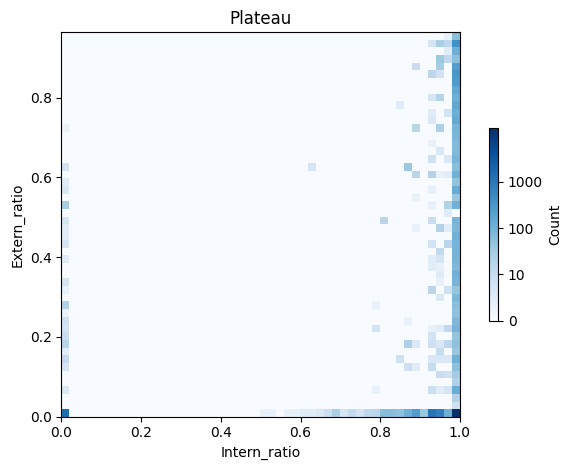

In [ ]:
# plot overlap between plateau groups
fig, axis=plt.subplots(1,1)
matrixplateau, xedges, yedges = np.histogram2d(plateau_overlap['intern_ratio'],plateau_overlap['extern_ratio'], bins=50)
matrixplateau[matrixplateau==0] = 0
matrixplateau[matrixplateau>0] = np.log10(matrixplateau[matrixplateau>0])
im1 = axis.imshow(np.flip(matrixplateau.T,0), extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')
cbar = plt.colorbar(im1, ax=axis,shrink=0.5, label='Count')
cbar.set_ticks(ticks=[0,1,2,3], labels=[0,10,100,1000])
plt.title('Plateau')
plt.xlabel('Intern_ratio')
plt.ylabel('Extern_ratio')
fig.tight_layout()

In [ ]:
# determine overlap for epicore results
epicore_df = pd.read_csv('UPN27/epicore_result.csv', index_col=[0])
epicore_df['grouped_peptides_start'] = epicore_df['grouped_peptides_start'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['grouped_peptides_end'] = epicore_df['grouped_peptides_end'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['grouped_peptides_sequence'] = epicore_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['core_epitopes_start'] = epicore_df['core_epitopes_start'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['core_epitopes_end'] = epicore_df['core_epitopes_end'].apply(lambda cell: ast.literal_eval(cell))
epicore_overlap = pd.concat([*epicore_df.apply(lambda row: all_overlap(row), axis=1)])
epicore_overlap["intern_ratio"] = epicore_overlap["intern_max"] / epicore_overlap["len_pep"]
epicore_overlap["extern_ratio"] = epicore_overlap.apply(
    lambda row: min(1, max(row["previous"], row["next"]) / row["len_pep"]), axis=1
)

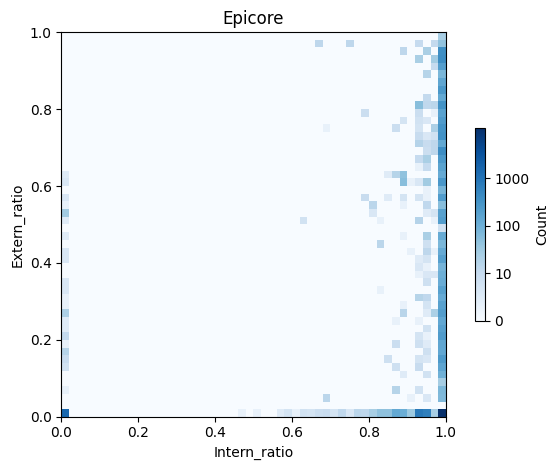

In [ ]:
# plot overlap between epicore groups
fig, axis=plt.subplots(1,1)
matrixepicore, xedges, yedges = np.histogram2d(epicore_overlap['intern_ratio'],epicore_overlap['extern_ratio'], bins=50)
matrixepicore[matrixepicore==0] = 0
matrixepicore[matrixepicore>0] = np.log10(matrixepicore[matrixepicore>0])
im1 = axis.imshow(np.flip(matrixepicore.T,0), extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')
cbar = plt.colorbar(im1, ax=axis,shrink=0.5, label='Count')
cbar.set_ticks(ticks=[0,1,2,3], labels=[0,10,100,1000])
plt.title('Epicore')
plt.xlabel('Intern_ratio')
plt.ylabel('Extern_ratio')
fig.tight_layout()
plt.show()

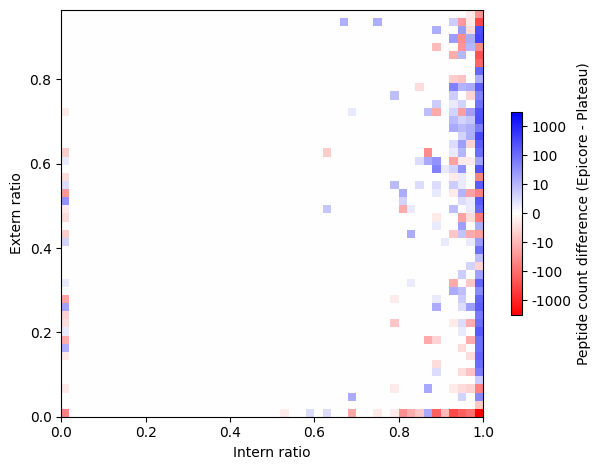

In [ ]:
# combine epicore and plateau overlaps in one plot
fig, axis = plt.subplots(ncols=1)

epicore_overlap["intern_ratio"] = epicore_overlap["intern_max"] / epicore_overlap["len_pep"]
plateau_overlap["intern_ratio"] = plateau_overlap["intern_max"] / plateau_overlap["len_pep"]
matrixepicore, xedges, yedges = np.histogram2d(epicore_overlap['intern_ratio'],epicore_overlap['extern_ratio'], bins=50)
matrixplateau, xedges, yedges = np.histogram2d(plateau_overlap['intern_ratio'],plateau_overlap['extern_ratio'], bins=50)

# normalize
#matrixepicore = (matrixepicore-np.min(matrixepicore))/(np.max(matrixepicore)- np.min(matrixepicore))
#matrixplateau = (matrixplateau-np.min(matrixplateau))/(np.max(matrixplateau)- np.min(matrixplateau))
matrix = matrixepicore - matrixplateau
matrix[matrix<0] = -np.log10(np.abs(matrix[matrix<0]))
matrix[matrix==0] = 0
matrix[matrix>0] = np.log10(matrix[matrix>0])
im1 = axis.imshow(np.flip(matrix.T,0), extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='bwr_r', norm=matplotlib.colors.CenteredNorm()) # more epicore
cbar = plt.colorbar(im1, ax=axis,shrink=0.5, label='Peptide count difference (Epicore - Plateau)')
cbar.set_ticks(ticks=[-3,-2,-1,0,1,2,3], labels=[-1000,-100,-10,0,10,100,1000])

plt.xlabel('Intern ratio')
plt.ylabel('Extern ratio')
fig.tight_layout()
plt.savefig('figures/ratio_epicore.svg')

In [15]:
print(f"{len(plateau_overlap[plateau_overlap['intern_ratio']>=0.8])/len(plateau_overlap)} peptides have intern ratios above 80% with plateau.")
print(f"{len(epicore_overlap[epicore_overlap['intern_ratio']>=0.8])/len(epicore_overlap)} peptides have intern ratios above 80% with epicore.")

0.9257712348027458 peptides have intern ratios above 80% with plateau.
0.9251534774198974 peptides have intern ratios above 80% with epicore.


In [16]:
print(f"{len(plateau_overlap[(plateau_overlap['intern_ratio']>=0.8)&(plateau_overlap['extern_ratio']<0.5)])/len(plateau_overlap)} peptides have intern ratios above 80% with plateau.")
print(f"{len(epicore_overlap[(epicore_overlap['intern_ratio']>=0.8)&(epicore_overlap['extern_ratio']<0.5)])/len(epicore_overlap)} peptides have intern ratios above 80% with epicore.")

0.7821106608220991 peptides have intern ratios above 80% with plateau.
0.6842570010932638 peptides have intern ratios above 80% with epicore.


In [18]:
print(f"{len(plateau_overlap[(plateau_overlap['intern_ratio']>=0.8)&(plateau_overlap['extern_ratio']==0)])/len(plateau_overlap)} peptides have extern ratios above 80% and no overlap with adjacent groups with plateau.")
print(f"{len(epicore_overlap[(epicore_overlap['intern_ratio']>=0.8)&(epicore_overlap['extern_ratio']==0)])/len(epicore_overlap)} peptides have extern ratios above 80% and no overlap with adjacent groups with epicore.")

0.7027127615581837 peptides have extern ratios above 80% and no overlap with adjacent groups with plateau.
0.545790934320074 peptides have extern ratios above 80% and no overlap with adjacent groups with epicore.


In [19]:
print(f"{len(plateau_overlap[(plateau_overlap['intern_ratio']>plateau_overlap['extern_ratio'])])/len(plateau_overlap)} peptides have higher intern ratios than extern ratios with plateau.")
print(f"{len(epicore_overlap[(epicore_overlap['intern_ratio']>epicore_overlap['extern_ratio'])])/len(epicore_overlap)} peptides have higher intern ratios than extern ratios with epicore.")

0.9289554213878091 peptides have higher intern ratios than extern ratios with plateau.
0.9264990328820116 peptides have higher intern ratios than extern ratios with epicore.


In [20]:
len(plateau_overlap[(plateau_overlap['intern_ratio']>=0.8)&(plateau_overlap['extern_ratio']==0)])

16993

In [21]:
len(epicore_overlap[(epicore_overlap['intern_ratio']>=0.8)&(epicore_overlap['extern_ratio']==0)])

12980

#### Compare sorted versus unsorted plateau results

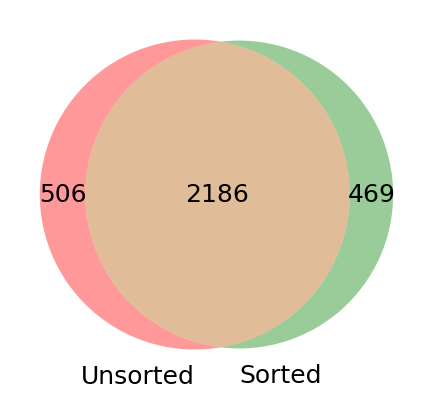

In [3]:
# load plateau output
plateau_df = pd.read_csv("unsorted_plateau_out.txt", sep='\t')
plateau_sorted = pd.read_csv("sorted_plateau_out.txt", sep='\t')

plateau = set(plateau_df.apply(lambda cell: f"{cell['Whole Epitope']}_{cell['Core Epitope'].replace('*','')}", axis=1))
plateau_sorted = set(plateau_sorted.apply(lambda cell: f"{cell['Whole Epitope']}_{cell['Core Epitope'].replace('*','')}", axis=1))
plot = venn2([plateau, plateau_sorted], ('Unsorted', 'Sorted'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)
plt.savefig('figures/overlap_candidates.svg')

In [4]:
print(f"Plateau identified {len(plateau_df)} peptide groups on unsorted data.")
print(f"Plateau identified {len(plateau_sorted)} peptide groups on sorted data.")

Plateau identified 2692 peptide groups on unsorted data.
Plateau identified 2655 peptide groups on sorted data.


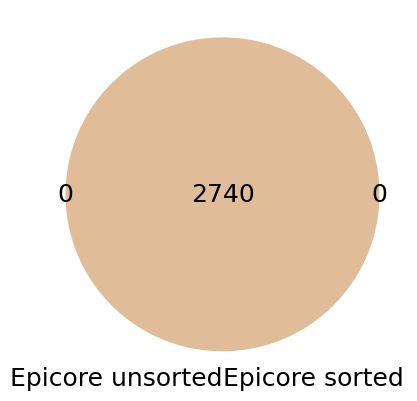

In [ ]:
# identify if input oder changes resulting peptide groups
epicore_sorted = pd.read_csv("UPN27_sorted/epitopes.csv")
epicore_unsorted = pd.read_csv("UPN27/epitopes.csv")

epicore_unsorted = set(epicore_unsorted['consensus_epitopes'])
epicore_sorted = set(epicore_sorted['consensus_epitopes'])
plot = venn2([epicore_unsorted, epicore_sorted], ('Epicore unsorted', 'Epicore sorted'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)

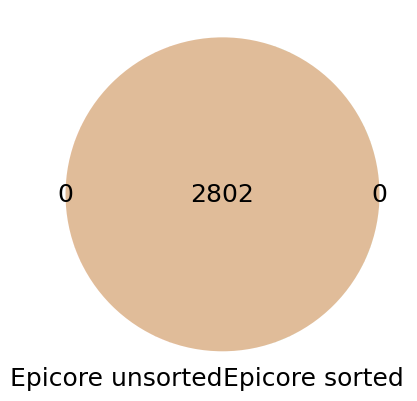

In [ ]:
# identify if input oder changes resulting peptide groups
epicore_sorted = pd.read_csv("UPN27_sorted/epitopes.csv")
epicore_unsorted = pd.read_csv("UPN27/epitopes.csv")

epicore_unsorted = set(epicore_unsorted['whole_epitopes'])
epicore_sorted = set(epicore_sorted['whole_epitopes'])
plot = venn2([epicore_unsorted, epicore_sorted], ('Epicore unsorted', 'Epicore sorted'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)